In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(42)
x,y = make_circles(n_samples=500,factor=0.1,noise=0.35,random_state=42)

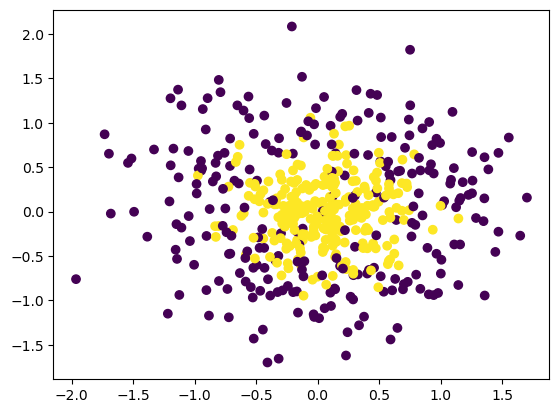

In [3]:
plt.scatter(x[:,0],x[:,1],c=y)

In [4]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

In [5]:
abc=AdaBoostClassifier()
np.mean(cross_val_score(abc,x,y,scoring="accuracy",cv=5))

np.float64(0.8200000000000001)

In [6]:
abc.fit(x,y)

AdaBoostClassifier()

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_regions(clf, x, y, title="Classifier Decision Regions"):
    plt.figure(figsize=(12,8))

    # Define ranges for grid
    x_min, x_max = x[:,0].min() - 1, x[:,0].max() + 1
    y_min, y_max = x[:,1].min() - 1, x[:,1].max() + 1
    
    xx1, xx2 = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # Predict over the grid
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)

    # Plot decision boundary
    plt.contourf(xx1, xx2, y_hat, alpha=0.2, cmap="viridis")

    # Plot data points
    plt.scatter(x[:,0], x[:,1], c=y, cmap="viridis", edgecolor="k", alpha=0.7)

    plt.title(title)
    plt.show()


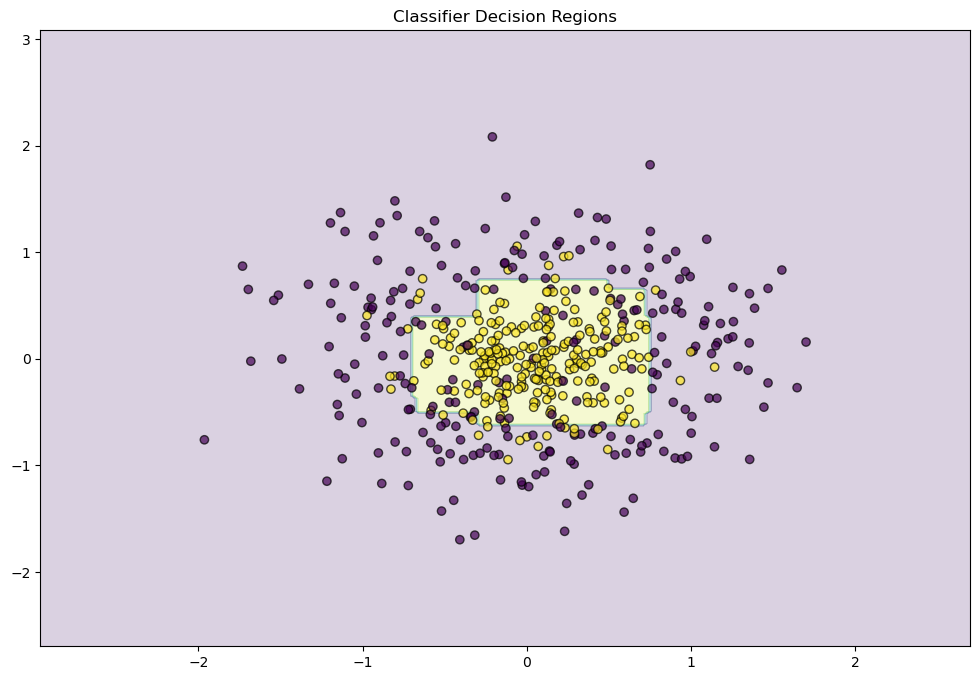

In [8]:
plot_decision_regions(abc,x,y)

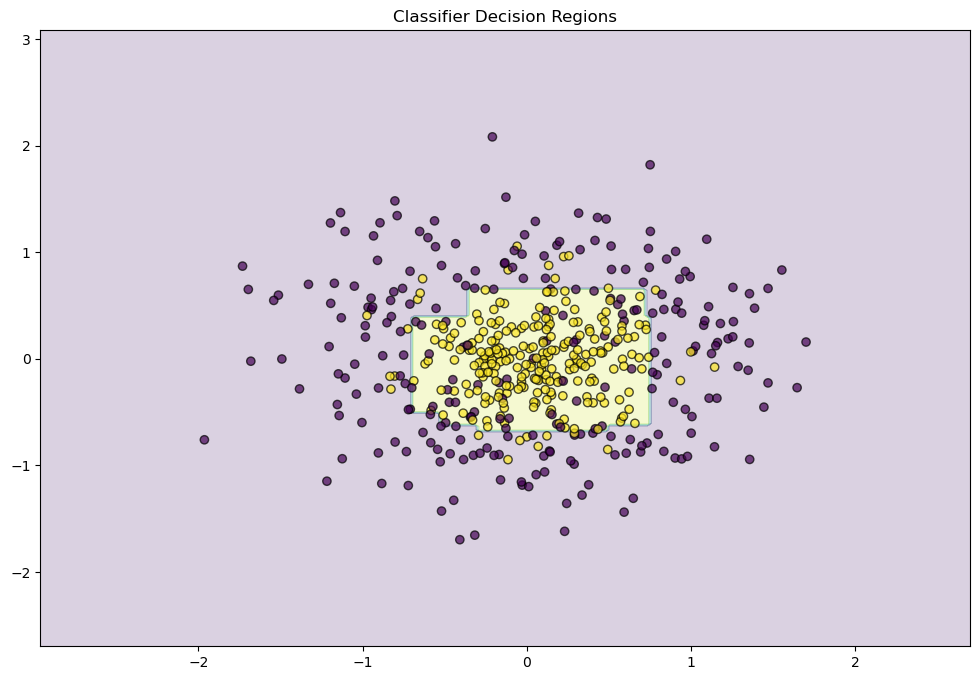

In [9]:
abc = AdaBoostClassifier(n_estimators=1500,learning_rate=0.1)
abc.fit(x,y)
plot_decision_regions(abc,x,y)

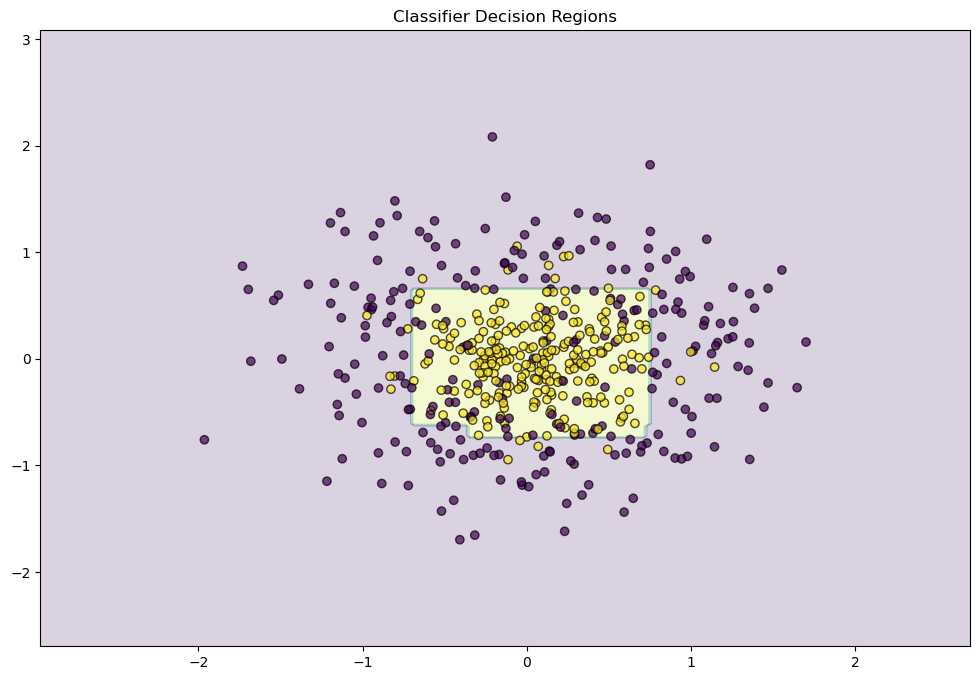

In [10]:
abc = AdaBoostClassifier(n_estimators=150,learning_rate=0.1)
abc.fit(x,y)
plot_decision_regions(abc,x,y)

In [11]:
from sklearn.model_selection import GridSearchCV
grid={}
grid["n_estimators"]=[1,10,100,1000,10000]
grid["learning_rate"]=[0.001,0.01,0.1,1,10]
grid["algorithm"]=["SAMME","SAMME.R"]

grid_search=GridSearchCV(estimator=AdaBoostClassifier(), param_grid=grid, scoring="accuracy", cv=5, n_jobs=-1)
grid_result=grid_search.fit(x,y)
print(grid_result.best_params_, grid_result.best_score)

C:\Users\heman\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
125 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
125 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\heman\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\heman\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\heman\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
 

AttributeError: 'GridSearchCV' object has no attribute 'best_score'